In [3]:
import os
import cdflib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


## Reading the data

In [4]:
# Directory containing all CDF files
cdf_directory = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//"

# List all CDF files in the directory
cdf_files = [os.path.join(cdf_directory, file) for file in os.listdir(cdf_directory) if file.endswith('.cdf')]

# Sort the list if necessary (e.g., chronological order)
cdf_files.sort()

print("CDF files to process:")
for file in cdf_files:
    print(file)


CDF files to process:
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232023_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232233_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232443_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232703

## Making Mask

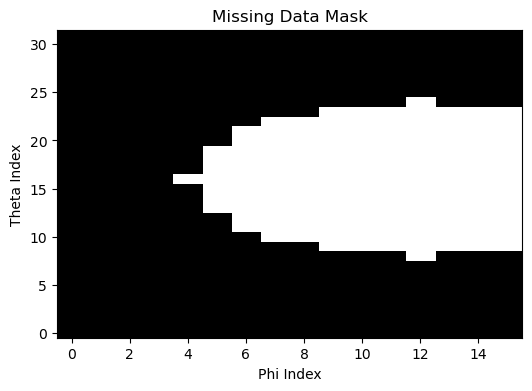

In [21]:
# Define the correct dimensions
theta_size = 32  # Theta dimension size
phi_size = 16    # Phi dimension size

# Create coordinate grids with updated sizes
phi_indices = np.arange(phi_size)
theta_indices = np.arange(theta_size)
phi_grid, theta_grid = np.meshgrid(phi_indices, theta_indices)

# Define the center and radius of the missing circle
center_phi = phi_size // 2 + 4  # Adjust as needed to position the circle
center_theta = theta_size // 2
radius = min(phi_size, theta_size) // 2  # Adjust radius as needed

# Create the mask
mask = np.zeros((theta_size, phi_size), dtype=bool)
distance_squared = (phi_grid - center_phi) ** 2 + (theta_grid - center_theta) ** 2
mask[distance_squared <= radius ** 2] = True  # True where data is missing

# Visualize the mask
plt.figure(figsize=(6, 4))
plt.imshow(mask, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask')
plt.xlabel('Phi Index')
plt.ylabel('Theta Index')
plt.show()


In [20]:
def load_and_preprocess_cdf(filepath, mask):
    """
    Load data from a CDF file, apply mask, and preprocess for model training.
    
    Parameters:
    - filepath (str): Path to the CDF file.
    - mask (numpy.ndarray): Boolean mask to apply to the data.
    
    Returns:
    - X (numpy.ndarray): Preprocessed data ready for model training.
    """
    with cdflib.CDF(filepath) as cdf_file:
        # Load variables
        dist_data = cdf_file.varget('mms1_des_dist_brst')  # Shape: (time_steps, energy_levels, phi_bins, theta_bins)
        phi_data = cdf_file.varget('mms1_des_phi_brst')    # Shape: (phi_bins,)
        theta_data = cdf_file.varget('mms1_des_theta_brst')  # Shape: (theta_bins,)
        energy_data = cdf_file.varget('mms1_des_energy_brst')  # Shape: (energy_levels,)
        epoch_data = cdf_file.varget('Epoch')  # Shape: (time_steps,)
    
    print(f"Loaded dist_data shape: {dist_data.shape}")
    
    # Reshape dist_data to (samples, phi_bins, theta_bins, energy_levels, 1)
    X = dist_data.reshape(-1, phi_size, theta_size, dist_data.shape[1], 1)  # Shape: (4333,16,32,32,1)
    
    # Apply mask: set missing data to 0.0
    # mask is (theta_size, phi_size) = (16,32)
    # To apply mask across all energy levels
    # Need to transpose X to (samples, theta, phi, energy_levels, 1)
    X_transposed = X.transpose(0, 2, 1, 3, 4)  # Shape: (4333,32,16,32,1)
    
    # Apply mask: set missing data to 0.0
    # Expand mask to match energy_levels and samples
    mask_expanded = np.expand_dims(mask, axis=(0, 3, 4))  # Shape: (1,32,16,1,1)
    mask_expanded = np.repeat(mask_expanded, X_transposed.shape[0], axis=0)  # Shape: (4333,32,16,1,1)
    mask_expanded = np.repeat(mask_expanded, dist_data.shape[1], axis=3)  # Shape: (4333,32,16,32,1)
    
    X_transposed[mask_expanded] = 0.0  # Set masked areas to 0.0
    
    # Transpose back to original shape
    X = X_transposed.transpose(0, 2, 1, 3, 4)  # Shape: (4333,16,32,32,1)
    
    return X


In [9]:
# Load a sample CDF file to determine energy_levels
sample_cdf = cdf_files[0]
with cdflib.CDF(sample_cdf) as cdf_file:
    dist_data = cdf_file.varget('mms1_des_dist_brst')
    energy_levels = dist_data.shape[1]
    print(f"Energy levels: {energy_levels}")


Energy levels: 32


In [18]:
# Define the input shape based on your data
input_shape = (phi_size, theta_size, energy_levels, 1)  # (32, 16, energy_levels, 1)
input_shape

(16, 32, 32, 1)

In [19]:
def build_autoencoder(input_shape):
    """
    Build and compile the autoencoder model.
    
    Parameters:
    - input_shape (tuple): Shape of the input data (phi, theta, energy_levels, channels).
    
    Returns:
    - autoencoder (Model): Compiled Keras model.
    """
    # Encoder
    input_img = Input(shape=input_shape)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling3D((2, 2, 2), padding='same')(x)
    
    # Decoder
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling3D((2, 2, 2))(x)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
    x = UpSampling3D((2, 2, 2))(x)
    decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)
    
    # Create the autoencoder model
    autoencoder = Model(inputs=input_img, outputs=decoded)
    
    # Compile the model
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder

# Build and compile the autoencoder
autoencoder = build_autoencoder(input_shape)
autoencoder.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 16, 32, 32, 1)]   0         
                                                                 
 conv3d_5 (Conv3D)           (None, 16, 32, 32, 32)    896       
                                                                 
 max_pooling3d_2 (MaxPoolin  (None, 8, 16, 16, 32)     0         
 g3D)                                                            
                                                                 
 conv3d_6 (Conv3D)           (None, 8, 16, 16, 64)     55360     
                                                                 
 max_pooling3d_3 (MaxPoolin  (None, 4, 8, 8, 64)       0         
 g3D)                                                            
                                                                 
 conv3d_7 (Conv3D)           (None, 4, 8, 8, 64)       1106

In [22]:
def incremental_train(autoencoder, cdf_files, mask, epochs=1, batch_size=1, output_weights_dir='model_weights'):
    """
    Train the autoencoder incrementally on multiple CDF files.
    
    Parameters:
    - autoencoder (Model): Compiled Keras model.
    - cdf_files (list): List of CDF file paths.
    - mask (numpy.ndarray): Boolean mask to apply to the data.
    - epochs (int): Number of epochs per CDF.
    - batch_size (int): Batch size for training.
    - output_weights_dir (str): Directory to save model weights after each CDF.
    
    Returns:
    - history (dict): Dictionary containing 'loss' and 'val_loss'.
    """
    os.makedirs(output_weights_dir, exist_ok=True)
    
    history = {'loss': [], 'val_loss': []}
    
    # Define callbacks
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    for idx, filepath in enumerate(cdf_files):
        print(f"\nProcessing CDF File {idx+1}/{len(cdf_files)}: {filepath}")
        
        # Load and preprocess data
        X = load_and_preprocess_cdf(filepath, mask=mask)
        
        # Check if there's enough data for training and validation
        if X.shape[0] < 2:
            print(f"Not enough samples in {filepath} for training. Skipping.")
            continue
        
        # Split into training and validation sets (90% train, 10% val)
        split_index = int(X.shape[0] * 0.9)
        X_train = X[:split_index]
        X_val = X[split_index:]
        
        print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")
        
        # Train the model
        history_step = autoencoder.fit(
            X_train, X_train,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=True,
            validation_data=(X_val, X_val),
            callbacks=[lr_scheduler, early_stopping],
            verbose=1
        )
        
        # Append history
        history['loss'].extend(history_step.history['loss'])
        history['val_loss'].extend(history_step.history['val_loss'])
        
        # Save model weights after this CDF
        weight_filename = f"autoencoder_weights_step_{idx+1}.h5"
        autoencoder.save_weights(os.path.join(output_weights_dir, weight_filename))
        print(f"Saved model weights to {os.path.join(output_weights_dir, weight_filename)}")
    
    return history


Number density: As described earlier.
Bulk velocity: Weighted by the phase space density and integrated over energy, azimuth, and elevation.
Pressure tensor: Involves the second moment of the velocity distribution.
Entropy: Using specific integrals, possibly linked with entropy flux.

In [23]:
# Execute incremental training
training_history = incremental_train(
    autoencoder=autoencoder,
    cdf_files=cdf_files,
    mask=mask,
    epochs=1,        # Adjust as needed (e.g., 10)
    batch_size=1,    # Adjust based on dataset size and memory 
    output_weights_dir='model_weights'
)



Processing CDF File 1/7: C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
Loaded dist_data shape: (4333, 32, 16, 32)
Training samples: 3899, Validation samples: 434

3899/3899 [==============================] - 53s 13ms/step - loss: 4.1080e-04 - val_loss: 1.3324e-10 - lr: 0.0010
Saved model weights to model_weights\autoencoder_weights_step_1.h5

Processing CDF File 2/7: C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf
Loaded dist_data shape: (5000, 32, 16, 32)
Training samples: 4500, Validation samples: 500
4500/4500 [==============================] - 60s 13ms/step - loss: 1.1366e-10 - val_loss: 9.0029e-11 - lr: 0.0010
Saved model weights to model_weights\autoencoder_weights_step_2.h5

Processing CDF File 3/7: C://Users//ryane//Desktop//Aurora_Project//MMS-

In [26]:
def plot_training_history(history):
    """
    Plot training and validation loss over time.
    
    Parameters:
    - history (dict): Dictionary containing 'loss' and 'val_loss'.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Autoencoder Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


In [28]:
# from sklearn.metrics import mean_squared_error, r2_score
# import numpy as np
# import matplotlib.pyplot as plt


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model

In [32]:
mms1_cdf_directory = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//"

MMS1 CDF files to process:
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232023_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232233_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232443_v3.4.0.cdf
C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_202403012

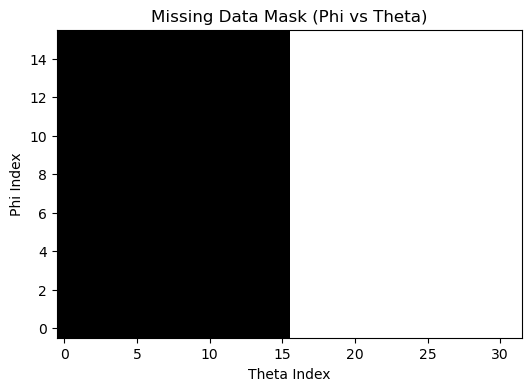

In [33]:
# Function to list and sort CDF files in a directory
def list_cdf_files(directory):
    cdf_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.cdf')]
    cdf_files.sort()
    if not cdf_files:
        raise ValueError(f"No CDF files found in the specified directory: {directory}")
    return cdf_files

# List and print MMS1 CDF files
mms1_cdf_files = list_cdf_files(mms1_cdf_directory)

print("MMS1 CDF files to process:")
for file in mms1_cdf_files:
    print(file)

# Step 3: Create the Missing Data Mask
# Define the mask to cover the right half of the theta_bins
# Assuming theta_bins = 32, phi_bins = 16 (based on previous data shapes)

energy_levels = 32
phi_bins = 16
theta_bins = 32

# Create a 2D mask for phi_bins x theta_bins
# Mask the right half: theta_bins >= 16
mask_2d = np.zeros((phi_bins, theta_bins), dtype=bool)
mask_2d[:, theta_bins//2:] = True  # Masking the right half

# Visualize the mask for one energy level (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()

In [34]:
# Step 4: Define a Function to Load and Preprocess CDF Data
def load_and_preprocess_cdf(filepath, var_name, mask=None):
    """
    Load data from a CDF file and apply mask if provided.
    
    Parameters:
    - filepath (str): Path to the CDF file.
    - var_name (str): Variable name to extract from the CDF file.
    - mask (numpy.ndarray or None): 2D boolean mask to apply to the data.
    
    Returns:
    - X (numpy.ndarray): Preprocessed data with mask applied if provided.
    - X_original (numpy.ndarray or None): Original data before masking (only if mask is provided).
    """
    with cdflib.CDF(filepath) as cdf_file:
        data = cdf_file.varget(var_name)  # Expected shape: (time_steps, energy_levels, phi_bins, theta_bins)
    
    print(f"Loaded data shape from {filepath}: {data.shape}")
    
    # Reshape to (samples, energy_levels, phi_bins, theta_bins, 1)
    X = data.reshape(-1, energy_levels, phi_bins, theta_bins, 1).astype('float32')
    
    if mask is not None:
        X_original = X.copy()
        # Expand mask to match data dimensions
        # mask shape: (phi_bins, theta_bins)
        # X shape: (samples, energy_levels, phi_bins, theta_bins, 1)
        mask_expanded = np.expand_dims(mask, axis=(0,1,4))  # Shape: (1,1,phi_bins, theta_bins,1)
        mask_broadcast = np.tile(mask_expanded, (X.shape[0], energy_levels, 1, 1, 1))  # Shape: (samples, energy_levels, phi_bins, theta_bins,1)
        # Apply mask: set masked regions to 0.0
        X[mask_broadcast] = 0.0
        return X, X_original
    else:
        return X, None


In [35]:
# Step 5: Load and Preprocess MMS1 Data (Training)
all_X_train = []
for file in mms1_cdf_files:
    X, _ = load_and_preprocess_cdf(file, 'mms1_des_dist_brst', mask=None)
    all_X_train.append(X)

# Stack all MMS1 data
all_X_train = np.vstack(all_X_train)  # Shape: (total_train_samples, 32,16,32,1)
print(f"Total training samples: {all_X_train.shape[0]}")

# Normalize training data
all_X_train /= np.max(all_X_train)

Loaded data shape from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf: (4333, 32, 16, 32)
Loaded data shape from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230953_v3.4.0.cdf: (5000, 32, 16, 32)
Loaded data shape from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232023_v3.4.0.cdf: (4330, 32, 16, 32)
Loaded data shape from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301232233_v3.4.0.cdf: (4334, 32, 16, 32)
Loaded data shape from C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_202403

Training samples: 25063, Validation samples: 6266
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 32, 16, 32, 1)]   0         
                                                                 
 conv3d_10 (Conv3D)          (None, 32, 16, 32, 32)    896       
                                                                 
 max_pooling3d_4 (MaxPoolin  (None, 16, 8, 16, 32)     0         
 g3D)                                                            
                                                                 
 conv3d_11 (Conv3D)          (None, 16, 8, 16, 64)     55360     
                                                                 
 max_pooling3d_5 (MaxPoolin  (None, 8, 4, 8, 64)       0         
 g3D)                                                            
                                                                 
 conv3d_1

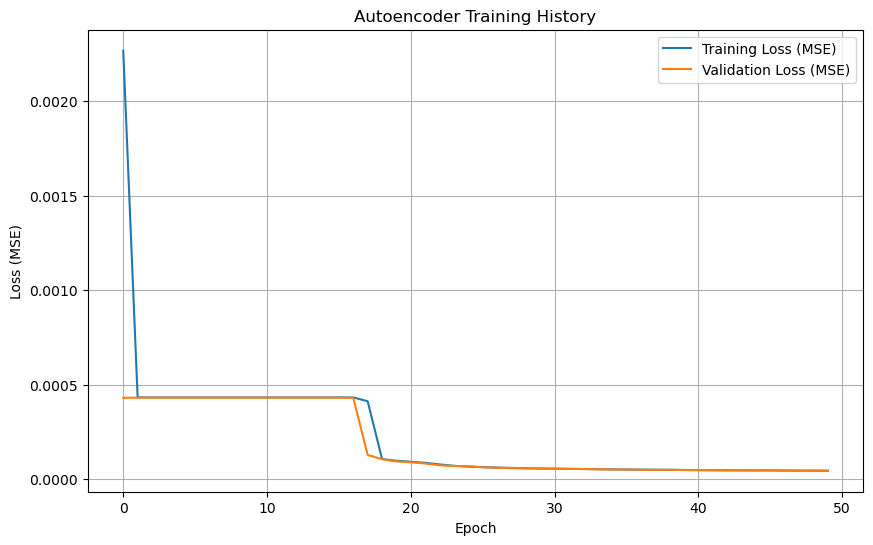

196/196 [==============================] - 17s 86ms/step
Validation Mean Squared Error (MSE) on masked regions: 6.7466362452250905e-06
Validation R² Score on masked regions: -10049457.566845104


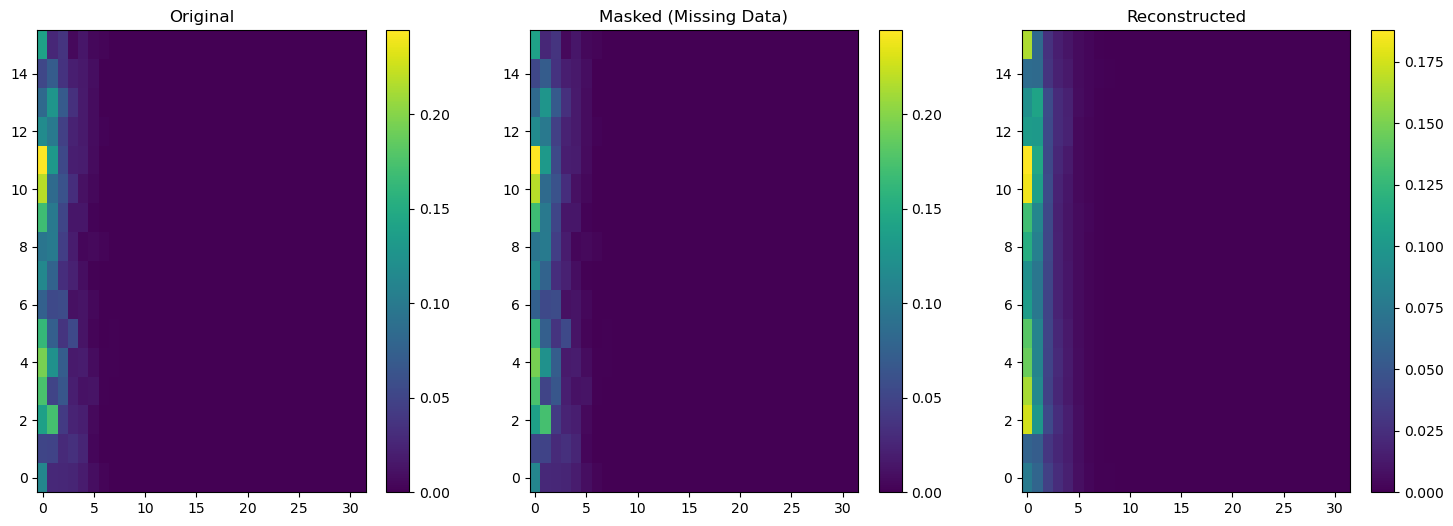

In [36]:
# Step 6: Split Data into Training and Validation Sets
X_train, X_val = train_test_split(all_X_train, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

# Step 7: Apply Mask to the Validation Set to Create Test Data
# This simulates missing data on the right half of the validation set

# Copy validation set to create masked version
X_val_masked = X_val.copy()

# Expand mask to match data dimensions
# mask_2d shape: (phi_bins, theta_bins)
# X_val_masked shape: (samples, energy_levels, phi_bins, theta_bins,1)
mask_expanded = np.expand_dims(mask_2d, axis=(0,1,4))  # Shape: (1,1,phi_bins, theta_bins,1)
mask_broadcast = np.tile(mask_expanded, (X_val_masked.shape[0], energy_levels, 1, 1, 1))  # Shape: (samples, energy_levels, phi_bins, theta_bins,1)

# Apply mask: set masked regions to 0.0
X_val_masked[mask_broadcast] = 0.0

# Step 8: Build and Compile the Autoencoder Model
def build_autoencoder(input_shape):
    """
    Build and compile the autoencoder model.
    
    Parameters:
    - input_shape (tuple): Shape of the input data (energy_levels, phi_bins, theta_bins, channels).
    
    Returns:
    - autoencoder (Model): Compiled Keras autoencoder model.
    """
    # Encoder
    input_img = Input(shape=input_shape)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling3D((2, 2, 2), padding='same')(x)
    
    # Decoder
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling3D((2, 2, 2))(x)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
    x = UpSampling3D((2, 2, 2))(x)
    decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)
    
    # Autoencoder Model
    autoencoder = Model(inputs=input_img, outputs=decoded)
    
    # Compile the model
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder

# Define input shape based on data
input_shape = (energy_levels, phi_bins, theta_bins, 1)  # (32,16,32,1)

# Build the autoencoder
autoencoder = build_autoencoder(input_shape)
autoencoder.summary()

# Step 9: Train the Autoencoder
epochs = 50
batch_size = 32

history = autoencoder.fit(
    X_train, X_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_val, X_val)
)

# Step 10: Plot Training History
def plot_training_history(history):
    """
    Plot training and validation loss over epochs.
    
    Parameters:
    - history: Keras History object.
    """
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Training Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title('Autoencoder Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(history)

# Step 11: Predict on Masked Validation Set
X_val_pred = autoencoder.predict(X_val_masked)

# Step 12: Evaluate the Model
# Calculate MSE and R² only on masked regions

# Extract the masked regions
masked_regions = X_val_masked == 0.0  # Boolean mask where data was masked

# Flatten the masked regions for actual and predicted data
actual = X_val[masked_regions].flatten()
predicted = X_val_pred[masked_regions].flatten()

# Calculate MSE and R²
mse = mean_squared_error(actual, predicted)
r2 = r2_score(actual, predicted)

print(f"Validation Mean Squared Error (MSE) on masked regions: {mse}")
print(f"Validation R² Score on masked regions: {r2}")

# Step 13: Visualize Some Reconstructions
# Select a random sample to visualize
sample_idx = np.random.randint(0, X_val.shape[0])

original_sample = X_val[sample_idx].reshape(energy_levels, phi_bins, theta_bins)
masked_sample = X_val_masked[sample_idx].reshape(energy_levels, phi_bins, theta_bins)
reconstructed_sample = X_val_pred[sample_idx].reshape(energy_levels, phi_bins, theta_bins)

# Choose an energy level to visualize
energy_level = 0  # Change as needed (0 to 31)

plt.figure(figsize=(18, 6))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original_sample[energy_level], aspect='auto', origin='lower', cmap='viridis')
plt.title('Original')
plt.colorbar()

# Masked
plt.subplot(1, 3, 2)
plt.imshow(masked_sample[energy_level], aspect='auto', origin='lower', cmap='viridis')
plt.title('Masked (Missing Data)')
plt.colorbar()

# Reconstructed
plt.subplot(1, 3, 3)
plt.imshow(reconstructed_sample[energy_level], aspect='auto', origin='lower', cmap='viridis')
plt.title('Reconstructed')
plt.colorbar()

plt.show()